# Vision Transformers for Geopotential ($Z_{500}$) Prediction

**Authors**: Matthias Karlbauer (ECMWF), Martin Janssens (WUR)

*This notebook was last tested and operational on 13/05/2026. Please [report any issues](https://github.com/ecmwf-training/2026-ml-esm-training/issues).*

<!-- :::{admonition} About
:class: note, dropdown -->
This notebook was developed for the DestinE [2026 Machine Learning for Earth System Modelling Course](https://learning.ecmwf.int/course/view.php?id=99). It provides a hands-on introduction to Vision Transformers applied to atmospheric forecasting.
<!-- ::: -->

<!-- :::{admonition} Running this notebook
:class: tip, dropdown -->
This notebook can be run/accessed on the following free online platforms. Please note they are not officially supported by or linked with ECMWF.

[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecmwf-training/2026-ml-esm-training/blob/main/m2/Transformer_z500_solved.ipynb)
[![kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-training/2026-ml-esm-training/blob/main/m2/Transformer_z500_solved.ipynb)
[![binder](https://mybinder.org/badge.svg)](https://mybinder.org/v2/gh/ecmwf-training/2026-ml-esm-training/main?labpath=m2/Transformer_z500_solved.ipynb)
[![github](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/ecmwf-training/2026-ml-esm-training/blob/main/m2/Transformer_z500_solved.ipynb)
<!-- 
::: -->

## Introduction

In this session, we will:

* Generate a synthetic but physically motivated dataset of $Z_{500}$ (geopotential at 500 hPa).
* Understand patchification: how to turn a 2D atmospheric field into a sequence of tokens.
* Build a Vision Transformer step-by-step and understand each component.
* Add coordinate embeddings to give the model geographic awareness.
* Train the model on a 1-step forecasting task.
* Evaluate predictions against a persistence baseline and visualise the results.

### Why Transformers for Atmospheric Data?

In the previous sessions you worked with Convolutional Neural Networks (CNNs) and Graph Neural Networks (GNNs). CNNs process data through local filters that slide across the grid: a 3×3 kernel sees only a 3×3 neighbourhood. This is a useful inductive bias for detecting local features, but may be a limitation when it comes to long-range dependencies (although this can be overcome).

To account for longer-range teleconnections (e.g. the influences across the Atlantic ocean of an anticyclone stationed over Greenland) more directly, we might turn to Transformers. The central mechanism of a Transformer, self-attention, lets every patch of the input directly attend to every other patch in a single operation, regardless of distance. This is why transformer-based models are very popular for medium-range weather prediction tasks.

### In this notebook

The steps we will follow are:

- Preparing the environment
- Generating and visualising synthetic $Z_{500}$ data
- Normalising the data
- Building a forecasting dataset and DataLoader
- Understanding patchification and verifying shapes
- Creating lat/lon coordinate embeddings
- Building the `PatchTransformer` architecture
- Training with a validation loop
- Evaluating and visualising the model predictions
- Bonus: adding periodic (circular) padding for longitude wrap-around

## Prepare your environment

The following packages are used in this notebook:

- `torch` and `torch.nn` for building and training the Transformer
- `numpy` for data generation and array operations
- `matplotlib` for visualisation

We begin by making sure these are installed.

In [1]:
%pip install -q -r https://raw.githubusercontent.com/ecmwf-training/2026-ml-esm-training/main/requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

## Generate synthetic $Z_{500}$ data

In this notebook, we will aim to predict $Z_{500}$, the geopotential at the 500 hPa pressure level in m²/s². It is one of the most commonly used variables in medium-range weather forecasting because it captures synpotic-scale patterns in high and low pressure. Typical values range from roughly 48 000 to 58 000 m²/s². The function below generates a synthetic time series of $Z_{500}$-like fields on a coarse (32 × 64) grid corresponding to roughly 5.6° resolution. The fields are:
1. Built on a physically motivated zonal mean that captures the latitudinal temperature gradient.
2. Perturbed with temporally autocorrelated, spatially smooth anomalies that mimic synoptic-scale weather patterns.

This is not real ERA5 data, but it has the right statistical structure to demonstrate how a Transformer learns spatial patterns.

In [3]:
def generate_z500(n_samples: int = 500, H: int = 32, W: int = 64, seed: int = 42) -> np.ndarray:
    """Generate synthetic Z500-like fields.  Returns array of shape (n_samples, H, W)."""
    rng = np.random.default_rng(seed)
    lats = np.linspace(-np.pi / 2, np.pi / 2, H)
    zonal_mean = (55000 - 3000 * np.abs(np.sin(lats)))[:, None]  # (H, 1)

    fields = np.zeros((n_samples, H, W), dtype=np.float32)
    perturb = rng.standard_normal((H, W)).astype(np.float32) * 500

    for t in range(n_samples):
        perturb = 0.97 * perturb + (rng.standard_normal((H, W)) * 150).astype(np.float32)
        for _ in range(3):
            p = np.pad(perturb, ((2, 2), (2, 2)), mode='wrap')
            blurred = sum(
                p[r:r + H, c:c + W]
                for r in range(5) for c in range(5)
            ) / 25
            perturb = blurred.astype(np.float32)
        fields[t] = zonal_mean + perturb

    return fields


H, W = 32, 64
z500_raw = generate_z500(n_samples=500, H=H, W=W)
print(f"Dataset shape : {z500_raw.shape}")
print(f"Value range   : {z500_raw.min():.0f} – {z500_raw.max():.0f} m²/s²")
print(f"Global mean   : {z500_raw.mean():.0f} m²/s²")
print(f"Global std    : {z500_raw.std():.0f} m²/s²")

Dataset shape : (500, 32, 64)
Value range   : 51877 – 54985 m²/s²
Global mean   : 53053 m²/s²
Global std    : 928 m²/s²


### Task: Normalise the data

Neural networks converge much faster when inputs have zero mean and unit variance (see the CNN notebook for an explanation of why). Fill in the `???` below to:
1. Compute `z500_mean` and `z500_std` as **scalar** statistics across the entire dataset.
2. Produce `z500_norm`, the normalised array of the same shape `(500, 32, 64)`.

After normalisation, verify that the mean is approximately 0 and the standard deviation approximately 1.

In [4]:
# Compute global statistics (scalars)
z500_mean = z500_raw.mean()
z500_std  = z500_raw.std()

# Normalise
z500_norm = (z500_raw - z500_mean) / z500_std

print(f"Normalised mean : {z500_norm.mean():.4f}  (expected ≈ 0)")
print(f"Normalised std  : {z500_norm.std():.4f}  (expected ≈ 1)")

Normalised mean : 0.0000  (expected ≈ 0)
Normalised std  : 1.0000  (expected ≈ 1)


### Visualise raw fields

Let's look at four snapshots of the raw (un-normalised) $Z_{500}$ field to confirm the data looks physically reasonable.

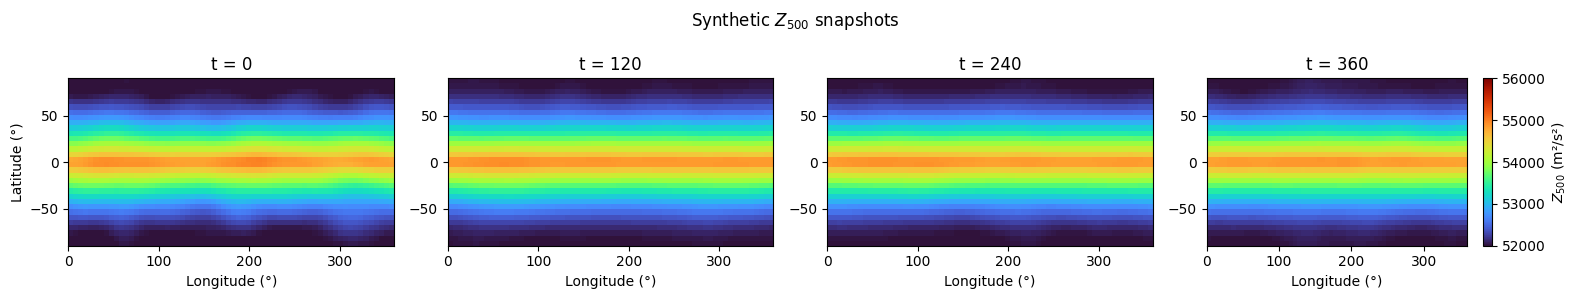

In [5]:
lats_deg = np.linspace(-90, 90, H)
lons_deg = np.linspace(0, 360, W, endpoint=False)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for i, ax in enumerate(axes):
    t = i * 120
    im = ax.imshow(z500_raw[t], origin='lower', aspect='auto',
                   extent=[0, 360, -90, 90], cmap='turbo',
                   vmin=52000, vmax=56000)
    ax.set_title(f"t = {t}")
    ax.set_xlabel("Longitude (°)")
    if i == 0:
        ax.set_ylabel("Latitude (°)")
plt.colorbar(im, ax=axes[-1], label="$Z_{500}$ (m²/s²)")
plt.suptitle("Synthetic $Z_{500}$ snapshots")
plt.tight_layout()
plt.show()

## Prediction Dataset and DataLoader

Let us say that we have a standard prediction task: Given the normalised $Z_{500}$ field at time step $t$, predict the field at time step $t + 1$. 

Both the input and target variables of this task will be tensors of shape `(1, H, W)` — one channel (geopotential) on a 2D grid. We will design a model to learn the mapping from the current state to the next state. 

To do that, we will train a transformer model on a part of the dataset; the trainin data. To do that, we split the synthetic $Z_{500}$ data generated above into 80% training / 20% validation.

In [6]:
# Prepare a torch dataset
class Z500Dataset(Dataset):
    def __init__(self, z500: np.ndarray, lead: int = 1):
        self.data = torch.from_numpy(z500).unsqueeze(1)  # (T, 1, H, W)
        self.lead = lead

    def __len__(self):
        return len(self.data) - self.lead

    def __getitem__(self, idx):
        return self.data[idx], self.data[idx + self.lead]

n_train = int(0.8 * len(z500_norm))
train_ds = Z500Dataset(z500_norm[:n_train])
val_ds   = Z500Dataset(z500_norm[n_train:])

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)

print(f"Training samples   : {len(train_ds)}")
print(f"Validation samples : {len(val_ds)}")
x_batch, y_batch = next(iter(train_loader))
print(f"Batch shapes       : input {tuple(x_batch.shape)},  target {tuple(y_batch.shape)}")

Training samples   : 399
Validation samples : 99
Batch shapes       : input (16, 1, 32, 64),  target (16, 1, 32, 64)


## Patchification

A Transformer processes a sequence of vectors (tokens), not a 2D grid. To use a Transformer on a spatial field, one usually uses *patchification*: A simple division of the 2D grid into non-overlapping rectangular patches. These patches are then flattened into vectors, and those vectors are treated as the tokens.

For a field of shape `(H, W) = (32, 64)` with patch size `P = 4`:

```
Grid 32 × 64
│  each row of 4×4 patches  │
┌────┬────┬────┬─ ─ ─ ─ ─ ─┬────┐
│ p0 │ p1 │ p2 │    ...    │p15 │   ← row 0 of patches (16 patches wide)
├────┼────┼────┼─ ─ ─ ─ ─ ─┼────┤
│p16 │p17 │p18 │    ...    │p31 │   ← row 1 of patches
│ …  │    │    │           │    │
└────┴────┴────┴─ ─ ─ ─ ─ ─┴────┘   8 rows × 16 cols = 128 patches
                                     each patch: 4×4 = 16 values
```

A smaller `P` gives more (shorter) tokens and finer spatial resolution but a longer sequence. That might prevent fine-scale features (fronts, sharp gradients) from being averaged away inside a patch, and allow the model to emphasise attention to finer spatial structure. However, halving `P` quadruples the number of tokens $N$. Since self-attention scales as $O(N^2)$, that increases computation and memory costs. More tokens also means there will be more positional embeddings to learn, which requires more data. For this notebook we use `P = 4`, giving 128 tokens per field.

### Utility functions

The two functions below implement the patchification, and its inverse operation.

In [7]:
PATCH_SIZE = 4

def patchify(x: torch.Tensor, P: int = PATCH_SIZE) -> torch.Tensor:
    """
    x: (B, C, H, W)
    Returns: (B, N, C*P*P)  where N = (H//P) * (W//P)
    """
    B, C, H, W = x.shape
    nh, nw = H // P, W // P
    x = x.reshape(B, C, nh, P, nw, P)
    x = x.permute(0, 2, 4, 1, 3, 5).contiguous()  # (B, nh, nw, C, P, P)
    x = x.reshape(B, nh * nw, C * P * P)
    return x


def unpatchify(patches: torch.Tensor, H: int, W: int, P: int = PATCH_SIZE) -> torch.Tensor:
    """
    patches: (B, N, P*P)  — single-channel output patches
    Returns: (B, 1, H, W)
    """
    B, N, _ = patches.shape
    nh, nw = H // P, W // P
    x = patches.reshape(B, nh, nw, P, P)
    x = x.permute(0, 1, 3, 2, 4).contiguous()  # (B, nh, P, nw, P)
    x = x.reshape(B, 1, H, W)
    return x

### Task: Verify patchify and unpatchify

Create `patches`, by running `patchify` on `x_batch` (shape `(16, 1, 32, 64)`). Confirm the output has shape `(16, 128, 16)`.

Then apply `unpatchify` to the result (store it in a variable `recovered`), treating the 16-value patches as single-channel patches, and confirm you recover shape `(16, 1, 32, 64)`.

In [8]:
patches = patchify(x_batch, P=PATCH_SIZE)
print(f"After patchify   : {tuple(patches.shape)}  (expected (16, 128, 16))")

recovered = unpatchify(patches, H=H, W=W, P=PATCH_SIZE)
print(f"After unpatchify : {tuple(recovered.shape)}  (expected (16, 1, 32, 64))")

After patchify   : (16, 128, 16)  (expected (16, 128, 16))
After unpatchify : (16, 1, 32, 64)  (expected (16, 1, 32, 64))


## Coordinate Embeddings

Standard image transformers treat all patches equally regardless of where they are in the image. But for atmospheric data, we expect there to be positional dependence in a field like $Z_{500}$: It should be high around the equator, lower towards the poles, and have large synoptic-scale zonal gradients in the midlatitudes.

We provide this information to the model by adding two extra channels to the input field before patchification:
- Latitude channel: linearly spaced from −1 (South Pole) to +1 (North Pole)
- Longitude channel: linearly spaced from −1 (0°) to +1 (360°)

After patchification, each token then contains both the $Z_{500}$ values and the lat/lon coordinates of its patch.

In [9]:
lats_norm = torch.linspace(-1, 1, H)
lons_norm = torch.linspace(-1, 1, W)

lat_grid, lon_grid = torch.meshgrid(lats_norm, lons_norm, indexing='ij')

latlon = torch.stack([lat_grid, lon_grid], dim=0)  # (2, H, W)

print(f"latlon shape : {tuple(latlon.shape)}")
print(f"lat  range   : {lat_grid.min():.2f} to {lat_grid.max():.2f}")
print(f"lon  range   : {lon_grid.min():.2f} to {lon_grid.max():.2f}")

latlon shape : (2, 32, 64)
lat  range   : -1.00 to 1.00
lon  range   : -1.00 to 1.00


## The PatchTransformer Architecture

### Self-attention

Given a sequence of $N$ token vectors (each of dimension $d$), self-attention computes three projections per token: a query $\mathbf{q}_i$, a key $\mathbf{k}_i$, and a value $\mathbf{v}_i$. The updated representation of token $i$ is a weighted sum of all value vectors, where the weight between tokens $i$ and $j$ is proportional to the dot-product of their query and key:

$$
\text{Attention} = \text{softmax}\!\left(\frac{\mathbf{q_i}\mathbf{k_j}^\top}{\sqrt{d}}\right)\mathbf{v_j}
$$

In the context of our weather prediction task, the attention weights learn which distant patches are relevant for predicting the local future state. For example, if we wish to predict temperature in Western Europe with a week's lead time in winter, we might expect that we want to pay close attention to the $Z_{500}$ gradient between Iceland and the Azores. Hence, the model might learn that for patches over Western Europe, it should give high attention values to the $Z_{500}$ patches over Iceland and the Azores.

### Architecture overview

With attention in our minds, let us now trace one batch of data step by step through the transformer architecture we are about to deploy. The shape of the batch of data at each stage is shown on the right. The explanation beneath each arrow describes what the operation does.

```
INPUT
  z500   (B, 1, H, W)       B samples, 1 channel, H=32 rows, W=64 columns
  latlon (B, 2, H, W)       B samples, 2 channels (latitude grid, longitude grid)
       │
       ▼  torch.cat along the channel dimension
  (B, 3, H, W)
```
We stack the $Z_{500}$ field and the two coordinate grids into a single tensor with 3 channels. Each grid cell now carries three numbers: its geopotential value, its latitude, and its longitude. The Transformer will see all three simultaneously for every patch.

```
       │
       ▼  patchify  — divide the grid into non-overlapping P×P blocks,
       │              flatten each block into a single vector
  (B, N, 3·P²)       N = (H/P)·(W/P) = 8×16 = 128 patches
                      each patch vector has 3 channels × P² = 3×16 = 48 values
```
This converts the 2D field into a sequence of $N$ tokens, as we already studied above. And with our choice of `P=4`, that means the token at each patch is now a vector containing 48 values.

```
       │
       ▼  patch_embedding  — one shared linear layer applied to every patch
       │   [nn.Linear: 3·P² → d_model]
  (B, N, d_model)           d_model = 64 in our model
```
A single `nn.Linear` layer maps the 48 raw numbers in each patch to a 64-dimensional embedding vector. This is a learned projection: the model discovers which combinations of pixel values and coordinates are most informative. The same linear transformation is applied to all 128 patches (i.e.g they share the same weight matrix), so the embedding is translation-equivariant.

```
       │
       +  pos_embedding  — add a learnable position vector to each token
       │   shape (1, N, d_model), broadcast over the batch
  (B, N, d_model)
```
Self-attention has no built-in sense of order. Without positional information, the token from patch 0 (top-left) and the token from patch 127 (bottom-right) would look identical to the model if they had the same pixel values. We of course added positional information already, by adding coordinate embeddings to the input. However, it is common to add this additional positional embedding, to reinforce to the model where in the grid a token came from, in case this information has been de-prioritised by the previous embedding layer. In prediction tasks that take an input over multiple time steps (e.g. a week's history), this positional embedding might additionally carry information on which time step a token is from.

```
       │
       ▼  TransformerEncoder  — num_layers=2 stacked attention + MLP blocks
  (B, N, d_model)             shape unchanged; each token has been updated
                               by attending to all other tokens
```
This is our transformer. Each of its 2 transformer blocks runs:
1. **Multi-head self-attention**: every token queries every other token, computes attention weights, and aggregates their values. After this step, each token's vector contains information gathered from across the entire grid.
2. **Feed-forward MLP**: a small two-layer network applied independently to each token, adding non-linearity and extra capacity.

The shapes going in and out of the encoder are identical — the encoder refines the token representations without changing their number or dimension.

```
       │
       ▼  output_head  — another linear layer applied to every token
       │   [nn.Linear: d_model → P²]
  (B, N, P²)                each token is now a flat vector of P²=16 pixel predictions
```
The encoder's d_model-dimensional token is decoded back into pixel space. Each token predicts the $P \times P = 16$ pixel values of its own patch at the next time step. There is no interaction between patches at this stage — the Transformer has already mixed information globally in the encoder; the output head just projects each result to the right size.

```
       │
       ▼  unpatchify  — reassemble the predicted patches into a full grid
  (B, 1, H, W)               one predicted Z500 field per sample

OUTPUT
```

### Task: Fill in the linear layer dimensions

Complete the `PatchTransformer.__init__` function by replacing the two `???` with the correct integer expressions.

Hints:
- `patch_embedding` receives a flattened patch from **3 channels** (z500 + lat + lon), each of size $P \times P$. What is the total number of values per patch?
- `output_head` must produce exactly **one predicted value per pixel** inside each patch, so the output dimension equals the number of pixels in a patch.

In [10]:
class PatchTransformer(nn.Module):
    def __init__(
        self,
        spatial_shape: tuple = (32, 64),
        patch_size: int = 4,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
    ):
        super().__init__()
        self.H, self.W = spatial_shape
        self.P = patch_size
        P = patch_size
        N = (self.H // P) * (self.W // P)

        # 3 channels (z500, lat, lon), each P×P pixels per patch
        self.patch_embedding = nn.Linear(3 * P * P, d_model)

        self.pos_embedding = nn.Parameter(torch.zeros(1, N, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            batch_first=True,
            dropout=0.0,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # P*P pixel values per patch (single output channel)
        self.output_head = nn.Linear(d_model, P * P)

    def forward(self, x: torch.Tensor, latlon: torch.Tensor) -> torch.Tensor:
        """
        x      : (B, 1, H, W)  normalised z500
        latlon : (2, H, W)     normalised lat/lon grids
        Returns: (B, 1, H, W)
        """
        B = x.shape[0]
        ll = latlon.unsqueeze(0).expand(B, -1, -1, -1)

        x_full = torch.cat([x, ll], dim=1)          # (B, 3, H, W)
        tokens = patchify(x_full, self.P)             # (B, N, 3*P²)
        tokens = self.patch_embedding(tokens) + self.pos_embedding
        tokens = self.transformer(tokens)
        out_patches = self.output_head(tokens)        # (B, N, P²)
        return unpatchify(out_patches, self.H, self.W, self.P)

In [11]:
model = PatchTransformer(spatial_shape=(H, W), patch_size=PATCH_SIZE, d_model=64, nhead=4, num_layers=2)
with torch.no_grad():
    out = model(x_batch, latlon)
print(f"Input  shape : {tuple(x_batch.shape)}")
print(f"Output shape : {tuple(out.shape)}  (expected (16, 1, 32, 64))")

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Input  shape : (16, 1, 32, 64)
Output shape : (16, 1, 32, 64)  (expected (16, 1, 32, 64))
Trainable parameters: 112,336


## Training

The cell below defines `train_one_epoch` and `evaluate` utility functions and runs the main training loop for 20 epochs with an Adam optimiser.

In [12]:
def train_one_epoch(model, loader, optimiser, criterion, latlon):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        optimiser.zero_grad()
        pred = model(x, latlon)
        loss = criterion(pred, y)
        loss.backward()
        optimiser.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, latlon):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            pred = model(x, latlon)
            loss = criterion(pred, y)
            total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

In [13]:
NUM_EPOCHS = 20
LR = 1e-3

model = PatchTransformer(spatial_shape=(H, W), patch_size=PATCH_SIZE, d_model=64, nhead=4, num_layers=2)
optimiser = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses = []
val_losses   = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimiser, criterion, latlon)
    train_losses.append(train_loss)

    val_loss = evaluate(model, val_loader, criterion, latlon)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}")

Epoch  1/20  train=0.1567  val=0.0265
Epoch  2/20  train=0.0111  val=0.0028
Epoch  3/20  train=0.0014  val=0.0011
Epoch  4/20  train=0.0007  val=0.0008
Epoch  5/20  train=0.0006  val=0.0007
Epoch  6/20  train=0.0006  val=0.0007
Epoch  7/20  train=0.0006  val=0.0007
Epoch  8/20  train=0.0005  val=0.0006
Epoch  9/20  train=0.0005  val=0.0007
Epoch 10/20  train=0.0005  val=0.0006
Epoch 11/20  train=0.0005  val=0.0006
Epoch 12/20  train=0.0005  val=0.0006
Epoch 13/20  train=0.0005  val=0.0006
Epoch 14/20  train=0.0005  val=0.0006
Epoch 15/20  train=0.0005  val=0.0005
Epoch 16/20  train=0.0005  val=0.0005
Epoch 17/20  train=0.0005  val=0.0006
Epoch 18/20  train=0.0005  val=0.0006
Epoch 19/20  train=0.0005  val=0.0005
Epoch 20/20  train=0.0005  val=0.0006


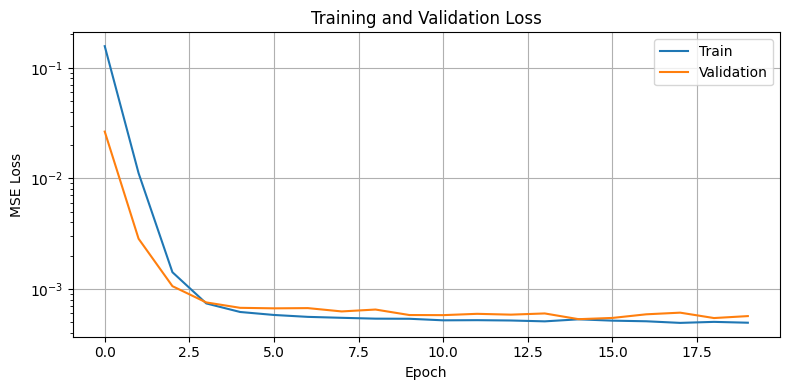

In [14]:
plt.figure(figsize=(8, 4))
plt.semilogy(train_losses, label="Train")
plt.plot(val_losses,   label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Evaluation and Visualisation

We now compare the model's predictions against the ground truth target field.

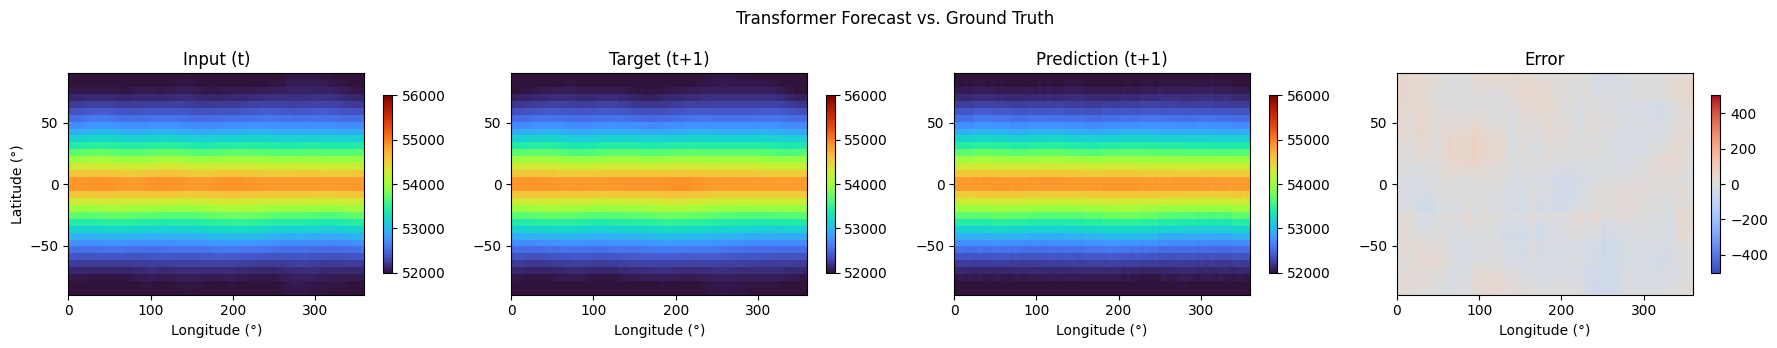

In [15]:
model.eval()

x_vis, y_vis = val_ds[0]
x_vis = x_vis.unsqueeze(0)
y_vis = y_vis.unsqueeze(0)

with torch.no_grad():
    pred_vis = model(x_vis, latlon)

def denorm(t):
    return t.squeeze().numpy() * z500_std + z500_mean

x_plot    = denorm(x_vis)
y_plot    = denorm(y_vis)
pred_plot = denorm(pred_vis)
error     = pred_plot - y_plot

fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
titles = ["Input (t)", "Target (t+1)", "Prediction (t+1)", "Error"]
data   = [x_plot, y_plot, pred_plot, error]
cmaps  = ["turbo", "turbo", "turbo", "coolwarm"]
vlims  = [(52000, 56000), (52000, 56000), (52000, 56000), (-500, 500)]

for ax, title, field, cmap, (vmin, vmax) in zip(axes, titles, data, cmaps, vlims):
    im = ax.imshow(field, origin='lower', aspect='auto',
                   extent=[0, 360, -90, 90], cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Longitude (°)")
    plt.colorbar(im, ax=ax, shrink=0.8)

axes[0].set_ylabel("Latitude (°)")
plt.suptitle("Transformer Forecast vs. Ground Truth")
plt.tight_layout()
plt.show()

It looks like the model didn't mess anything up, and that the errors are relatively small. But of course, the model also didn't have to do too much in this task, since the target still is very similar in its dominant patterns to the original input. Therefore, we might evalute the model performance more meaningfully by comparing it to a *persistence baseline*, i.e. the model where we just assume the target is equal to the input. We evaluate the errors of both the persistence model and our transformer model in the cell below.

In [16]:
all_preds, all_targets, all_inputs = [], [], []
model.eval()
with torch.no_grad():
    for x, y in val_loader:
        pred = model(x, latlon)
        all_preds.append(pred)
        all_targets.append(y)
        all_inputs.append(x)

preds   = torch.cat(all_preds)
targets = torch.cat(all_targets)
inputs  = torch.cat(all_inputs)

rmse_model       = ((preds - targets) ** 2).mean().sqrt().item()
rmse_persistence = ((inputs - targets) ** 2).mean().sqrt().item()

print(f"RMSE – Transformer  : {rmse_model:.4f} (normalised units)")
print(f"RMSE – Persistence  : {rmse_persistence:.4f} (normalised units)")
print(f"Improvement over persistence: {(1 - rmse_model / rmse_persistence) * 100:.1f}%")
print()
print(f"RMSE – Transformer  : {rmse_model * z500_std:.1f} m²/s² (physical units)")
print(f"RMSE – Persistence  : {rmse_persistence * z500_std:.1f} m²/s² (physical units)")

RMSE – Transformer  : 0.0238 (normalised units)
RMSE – Persistence  : 0.0197 (normalised units)
Improvement over persistence: -20.6%

RMSE – Transformer  : 22.1 m²/s² (physical units)
RMSE – Persistence  : 18.3 m²/s² (physical units)


Since the model is trained on synthetic data with a prescribed autocorrelation structure, the improvement over the persistence model reflects how well the transformer has learned the temporal dynamics of this autocorrelation. For meaningful forecast skill scores, we would have to train on real data, use a larger model, and evaluate our performance over years of data that the model didn't see during training. We would also want to include many more variables, let those variables interact with each other inside the model etc. We will discuss such full AI weather prediction models in Module 5 of the course.

## Bonus example: Periodic Padding for Longitude

The Earth's longitude is periodic: 0° and 360° are the same meridian. When our Transformer splits the 64-longitude field into non-overlapping patches, the patches at the left edge (near 0°) and the right edge (near 360°) are treated as unrelated — even though they are geographically adjacent.

Circular padding solves this by taking the `P` columns from the right side of the field and prepending them to the left side (and vice versa). After padding, the first and last patches each see a mix of values from both sides of the date line.

In [17]:
class PatchTransformerPeriodic(nn.Module):
    def __init__(
        self,
        spatial_shape: tuple = (32, 64),
        patch_size: int = 4,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
    ):
        super().__init__()
        self.H, self.W = spatial_shape
        self.P = patch_size
        P = patch_size
        # With circular padding the padded width is W + 2*P
        N = (self.H // P) * ((self.W + 2 * P) // P)

        self.patch_embedding = nn.Linear(3 * P * P, d_model)
        self.pos_embedding    = nn.Parameter(torch.zeros(1, N, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            batch_first=True, dropout=0.0,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_head = nn.Linear(d_model, P * P)

    def forward(self, x: torch.Tensor, latlon: torch.Tensor) -> torch.Tensor:
        B = x.shape[0]
        P = self.P
        ll = latlon.unsqueeze(0).expand(B, -1, -1, -1)
        x_full = torch.cat([x, ll], dim=1)  # (B, 3, H, W)

        # Circular padding in longitude direction
        x_padded = F.pad(x_full, (P, P, 0, 0), mode='circular')  # (B, 3, H, W+2P)

        W_padded = self.W + 2 * P
        tokens = patchify(x_padded, P)                           # (B, N_padded, 3*P²)

        tokens = self.patch_embedding(tokens) + self.pos_embedding
        tokens = self.transformer(tokens)
        out_patches = self.output_head(tokens)

        out_full = unpatchify(out_patches, self.H, W_padded, P)  # (B, 1, H, W+2P)
        out = out_full[:, :, :, P: P + self.W]                   # (B, 1, H, W)
        return out


model_periodic = PatchTransformerPeriodic(spatial_shape=(H, W), patch_size=PATCH_SIZE)
with torch.no_grad():
    out_p = model_periodic(x_batch, latlon)
print(f"Periodic model output shape: {tuple(out_p.shape)}  (expected (16, 1, 32, 64))")

Periodic model output shape: (16, 1, 32, 64)  (expected (16, 1, 32, 64))
